# Assignment 1 - Dynamic Programming

**Frozen Lake - 4x5 Gridworld · Summer Semester 2026**

| | |
|---|---|
| **Name** | `Nihat Garibli` |
| **ID** | `5425819` |

Find the optimal policy π\* and the optimal state-value function V\* by solving the MDP with **Policy Iteration** and **Value Iteration**, and compare the two methods.

In [1]:
# gymnasium is pre-installed on Colab; install it only if it is missing.
try:
    import gymnasium  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gymnasium"])

import time

import numpy as np
import gymnasium as gym
from gymnasium.spaces import Discrete

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="white")

## 1. The environment

```
 S  F  F  F  F        states  0.. 4
 F  F  F  H  F        states  5.. 9   (hole at state 8)
 F  F  F  F  F        states 10..14
 H  F  F  F  G        states 15..19   (hole at 15, goal at 19)
```

Exactly as specified in the assignment sheet:

| Setting | Value |
|---|---|
| Step reward (**every** transition) | −0.08 |
| Goal / hole | +1 / −1, **added on top** of the step reward |
| P(intended direction) | 0.8 |
| P(slip to each perpendicular side) | 0.1 + 0.1 |
| Walls | rigid - the agent stays in place |
| Discount γ | 0.95 |
| Start state | uniformly random over the 17 non-terminal squares |

Actions: `0 = ← (W)`, `1 = ↓ (S)`, `2 = → (E)`, `3 = ↑ (N)`.

The step cost is what makes the task interesting: dawdling is expensive, so the
optimal policy has to trade off the **shortest** path against the **safest** path
around the two holes.

The environment exposes the full model as
`P[s][a] = [(prob, next_state, reward, terminated), ...]`, which is what the
Dynamic-Programming methods need; the model-free methods only use
`reset()` / `step()`.

In [2]:
# ---- constants, taken directly from the assignment sheet -------------------
GAMMA = 0.95
STEP_REWARD = -0.08
GOAL_REWARD = 1.0
HOLE_REWARD = -1.0
SLIP_PROB = 0.2

ACTION_ARROWS = ["←", "↓", "→", "↑"]          # left, down, right, up
ACTION_NAMES = ["W (left)", "S (down)", "E (right)", "N (up)"]

SEED = 0

# Filled in by the algorithms; used for the timing / iteration tables.
RUN_STATS = {}

# Module level RNG, so that a whole run is reproducible via set_seed().
RNG = np.random.default_rng(SEED)


def set_seed(seed):
    """Seed the module RNG (used by the epsilon-greedy behaviour policy)."""
    global RNG
    RNG = np.random.default_rng(seed)

In [3]:
class CustomFrozenLakeEnv(gym.Env):
    """A customised 4x5 FrozenLake that follows the gymnasium Env API.

    The full model (transition probabilities and rewards) is exposed through
    ``self.P[s][a] = [(prob, next_state, reward, terminated), ...]`` which is
    exactly what the Dynamic Programming algorithms of Assignment 1 need.
    """

    metadata = {"render_modes": ["ansi"], "render_fps": 4}

    def __init__(
        self,
        map_name="4x5",
        is_slippery=True,
        slip_prob=SLIP_PROB,
        step_reward=STEP_REWARD,
        goal_reward=GOAL_REWARD,
        hole_reward=HOLE_REWARD,
        random_start=True,
        render_mode=None,
    ):
        self.map_name = map_name
        self.is_slippery = is_slippery
        self.slip_prob = slip_prob
        self.step_reward = step_reward
        self.goal_reward = goal_reward
        self.hole_reward = hole_reward
        self.random_start = random_start
        self.render_mode = render_mode

        #  S F F F F
        #  F F F H F
        #  F F F F F
        #  H F F F G
        self.desc = np.asarray(["SFFFF", "FFFHF", "FFFFF", "HFFFG"], dtype="c")

        self.nrow, self.ncol = self.desc.shape
        self.nA = 4
        self.nS = self.nrow * self.ncol

        flat = self.desc.reshape(-1)
        self.terminal_states = np.array([bytes(c) in b"GH" for c in flat])
        self.hole_states = np.array([bytes(c) == b"H" for c in flat])
        self.goal_states = np.array([bytes(c) == b"G" for c in flat])
        # Episodes start in any non-terminal square (assignment: random start state).
        self.start_states = np.flatnonzero(~self.terminal_states)

        self.P = {s: {a: [] for a in range(self.nA)} for s in range(self.nS)}
        self._init_transitions()
        self._build_sampling_tables()

        self.observation_space = Discrete(self.nS)
        self.action_space = Discrete(self.nA)

        self.s = int(self.start_states[0])

    # ------------------------------------------------------------------ #
    # geometry helpers
    # ------------------------------------------------------------------ #
    def to_s(self, row, col):
        return row * self.ncol + col

    def inc(self, row, col, a):
        """Move one square in direction ``a``; the walls are rigid."""
        if a == 0:      # left  (W)
            col = max(col - 1, 0)
        elif a == 1:    # down  (S)
            row = min(row + 1, self.nrow - 1)
        elif a == 2:    # right (E)
            col = min(col + 1, self.ncol - 1)
        elif a == 3:    # up    (N)
            row = max(row - 1, 0)
        return (row, col)

    def _reward(self, newletter):
        """Step cost on every transition, plus the terminal bonus / penalty."""
        r = self.step_reward
        if newletter == b"G":
            r += self.goal_reward
        elif newletter == b"H":
            r += self.hole_reward
        return float(r)

    # ------------------------------------------------------------------ #
    # the model  P[s][a] -> [(prob, s', r, done), ...]
    # ------------------------------------------------------------------ #
    def _init_transitions(self):
        for row in range(self.nrow):
            for col in range(self.ncol):
                s = self.to_s(row, col)
                letter = self.desc[row, col]
                for a in range(self.nA):
                    li = self.P[s][a]
                    if bytes(letter) in b"GH":
                        # Absorbing terminal state: no further reward.
                        li.append((1.0, s, 0.0, True))
                        continue

                    if self.is_slippery:
                        # (a-1)%4 and (a+1)%4 are the two perpendicular
                        # directions  =>  0.8 / 0.1 / 0.1 as required.
                        moves = [((a - 1) % 4, self.slip_prob / 2),
                                 (a, 1.0 - self.slip_prob),
                                 ((a + 1) % 4, self.slip_prob / 2)]
                    else:
                        moves = [(a, 1.0)]

                    for b, prob in moves:
                        newrow, newcol = self.inc(row, col, b)
                        newstate = self.to_s(newrow, newcol)
                        newletter = self.desc[newrow, newcol]
                        done = bytes(newletter) in b"GH"
                        li.append((prob, newstate, self._reward(newletter), done))

    def _build_sampling_tables(self):
        """Pre-compute cumulative probabilities so that step() stays cheap."""
        self._cum, self._nxt, self._rew, self._done = {}, {}, {}, {}
        for s in range(self.nS):
            for a in range(self.nA):
                tr = self.P[s][a]
                self._cum[(s, a)] = np.cumsum([t[0] for t in tr])
                self._nxt[(s, a)] = np.array([t[1] for t in tr], dtype=np.int64)
                self._rew[(s, a)] = np.array([t[2] for t in tr], dtype=np.float64)
                self._done[(s, a)] = np.array([t[3] for t in tr], dtype=bool)

    # ------------------------------------------------------------------ #
    # gymnasium API
    # ------------------------------------------------------------------ #
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if options is not None and "state" in options:
            self.s = int(options["state"])
        elif self.random_start:
            self.s = int(self.np_random.choice(self.start_states))
        else:
            self.s = 0
        return self.s, {}

    def step(self, a):
        key = (self.s, int(a))
        i = int(np.searchsorted(self._cum[key], self.np_random.random()))
        i = min(i, len(self._nxt[key]) - 1)          # guard against float rounding
        self.s = int(self._nxt[key][i])
        return self.s, float(self._rew[key][i]), bool(self._done[key][i]), False, {}

    def render(self):
        out = []
        for row in range(self.nrow):
            line = ""
            for col in range(self.ncol):
                c = self.desc[row, col].decode("utf-8")
                line += "[%s]" % c if self.to_s(row, col) == self.s else " %s " % c
            out.append(line)
        return "\n".join(out)

In [4]:
# Register the custom environment and create it through the gymnasium API.
if "CustomFrozenLake-v0" not in gym.registry:
    gym.envs.registration.register(
        id="CustomFrozenLake-v0",
        entry_point=CustomFrozenLakeEnv,
        max_episode_steps=200,        # safety net -> truncation, not termination
    )

env = gym.make("CustomFrozenLake-v0", is_slippery=True, slip_prob=SLIP_PROB,
               disable_env_checker=True)
env.reset(seed=SEED)
set_seed(SEED)

print("Grid  (S=start, F=frozen, H=hole, G=goal):")
print(env.unwrapped.render())
print("\ngamma=%.2f   step reward=%.2f   P(intended)=%.1f   P(slip to each side)=%.1f"
      % (GAMMA, STEP_REWARD, 1 - SLIP_PROB, SLIP_PROB / 2))
print("start states:", env.unwrapped.start_states)

Grid  (S=start, F=frozen, H=hole, G=goal):
 S  F  F  F  F 
 F  F  F  H  F 
 F  F  F  F  F 
 H [F] F  F  G 

gamma=0.95   step reward=-0.08   P(intended)=0.8   P(slip to each side)=0.1
start states: [ 0  1  2  3  4  5  6  7  9 10 11 12 13 14 16 17 18]


## 2. Plotting helpers

Every figure gets a title, axis labels and readable annotations; terminal squares
are marked `H` / `G` instead of an arrow.

In [5]:
def _finish(fname=None):
    plt.tight_layout()
    plt.show()


def _cell_labels(env=None):
    """Letter of every square, used to mark H / G on the plots."""
    desc = env.desc if env is not None else np.asarray(
        ["SFFFF", "FFFHF", "FFFFF", "HFFFG"], dtype="c")
    return np.array([[c.decode() for c in row] for row in desc])


def _slug(title):
    return title.replace(" ", "_").replace("/", "-").replace("(", "").replace(")", "")


def plot_value_function(V, title="Value Function", env=None):
    """Heat-map of the state-value function V(s) over the 4x5 grid."""
    V = np.asarray(V, dtype=float).reshape((4, 5))
    labels = _cell_labels(env)
    annot = np.array([["%.2f\n%s" % (V[r, c], labels[r, c]) if labels[r, c] in "HG"
                       else "%.2f" % V[r, c] for c in range(5)] for r in range(4)])
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(V, annot=annot, fmt="", cmap="coolwarm", cbar=True,
                square=True, linewidths=0.5, linecolor="grey")
    plt.title(title)
    plt.xlabel("column")
    plt.ylabel("row")
    _finish(_slug(title) + ".png")


def plot_policy(P, title="Policy", env=None, V=None):
    """Arrow map of a deterministic policy; terminal squares show H / G."""
    P = np.asarray(P).reshape((4, 5))
    labels = _cell_labels(env)
    arrows = np.array([[labels[r, c] if labels[r, c] in "HG"
                        else ACTION_ARROWS[int(P[r, c])]
                        for c in range(5)] for r in range(4)])
    background = np.zeros((4, 5)) if V is None else np.asarray(V, float).reshape(4, 5)
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(background, annot=arrows, fmt="", cbar=V is not None,
                cmap="coolwarm", square=True, linewidths=0.5, linecolor="grey",
                annot_kws={"size": 20})
    plt.title(title)
    plt.xlabel("column")
    plt.ylabel("row")
    _finish(_slug(title) + ".png")


def print_policy(policy, env, title=""):
    """ASCII version of the policy, handy for the written report."""
    labels = _cell_labels(env)
    policy = np.asarray(policy).reshape(4, 5)
    print("\n" + title)
    for r in range(4):
        print("  " + "  ".join(labels[r, c] if labels[r, c] in "HG"
                               else ACTION_ARROWS[int(policy[r, c])] for c in range(5)))

## 3. Policy Iteration

Alternate two steps until the policy stops changing:

1. **Policy evaluation** - solve $V^{\pi}$ for the current policy by sweeping

$$V(s) \leftarrow \sum_{s'} P(s'|s,\pi(s))\,[\,r + \gamma V(s')\,]$$

2. **Policy improvement** - act greedily w.r.t. the value just computed

$$\pi(s) \leftarrow \arg\max_a \sum_{s'} P(s'|s,a)\,[\,r + \gamma V(s')\,]$$

When the greedy policy no longer changes, it is **provably optimal** - the
algorithm terminates exactly, with no threshold involved.

In [6]:
def _q_from_v(P, s, V, gamma, nA):
    """One-step look-ahead: Q(s, a) for every a, given V."""
    q = np.zeros(nA)
    for a in range(nA):
        q[a] = sum(p * (r + gamma * V[s2] * (not done)) for p, s2, r, done in P[s][a])
    return q


def policy_evaluation(P, nS, nA, policy, gamma=GAMMA, theta=1e-10):
    """Iterative policy evaluation of a deterministic policy (in-place sweeps)."""
    V = np.zeros(nS)
    sweeps = 0
    while True:
        delta = 0.0
        for s in range(nS):
            v_old = V[s]
            a = int(policy[s])
            V[s] = sum(p * (r + gamma * V[s2] * (not done))
                       for p, s2, r, done in P[s][a])
            delta = max(delta, abs(v_old - V[s]))
        sweeps += 1
        if delta < theta:
            return V, sweeps


def policy_iteration(env, gamma=GAMMA, theta=1e-10, verbose=True):
    """Assignment 1a -- Policy Iteration: evaluate -> improve -> repeat."""
    env = env.unwrapped
    P, nS, nA = env.P, env.nS, env.nA
    policy = np.zeros(nS, dtype=int)
    t0 = time.perf_counter()
    n_iter, total_sweeps = 0, 0

    while True:
        V, sweeps = policy_evaluation(P, nS, nA, policy, gamma, theta)
        total_sweeps += sweeps
        n_iter += 1
        stable = True
        for s in range(nS):
            old_a = policy[s]
            policy[s] = int(np.argmax(_q_from_v(P, s, V, gamma, nA)))
            if old_a != policy[s]:
                stable = False
        if stable:                      # greedy policy no longer changes -> optimal
            break

    elapsed = time.perf_counter() - t0
    RUN_STATS["Policy Iteration"] = {"iterations": n_iter, "sweeps": total_sweeps,
                                     "time_s": elapsed}
    if verbose:
        print("[Policy Iteration] converged after %d policy improvements "
              "(%d evaluation sweeps) -- %.1f ms" % (n_iter, total_sweeps, elapsed * 1e3))
    return policy, V

## 4. Value Iteration

Skip the inner evaluation loop entirely and apply the Bellman **optimality**
backup directly:

$$V(s) \leftarrow \max_a \sum_{s'} P(s'|s,a)\,[\,r + \gamma V(s')\,]$$

Sweeps stop when $\max_s |\Delta V(s)| < \theta$, and one final greedy pass
extracts π\* from V\*.

In [7]:
def value_iteration(env, gamma=GAMMA, theta=1e-10, verbose=True):
    """Assignment 1b -- Value Iteration: repeated Bellman optimality backup."""
    env = env.unwrapped
    P, nS, nA = env.P, env.nS, env.nA
    V = np.zeros(nS)
    t0 = time.perf_counter()
    sweeps = 0

    while True:
        delta = 0.0
        for s in range(nS):
            v_old = V[s]
            V[s] = np.max(_q_from_v(P, s, V, gamma, nA))
            delta = max(delta, abs(v_old - V[s]))
        sweeps += 1
        if delta < theta:
            break

    # A single greedy pass extracts the optimal policy from V*.
    policy = np.array([int(np.argmax(_q_from_v(P, s, V, gamma, nA)))
                       for s in range(nS)])

    elapsed = time.perf_counter() - t0
    RUN_STATS["Value Iteration"] = {"iterations": sweeps, "sweeps": sweeps,
                                    "time_s": elapsed}
    if verbose:
        print("[Value Iteration]  converged after %d sweeps -- %.1f ms"
              % (sweeps, elapsed * 1e3))
    return policy, V

## 5. Run both methods

In [8]:
policy_pi, V_pi = policy_iteration(env, gamma=GAMMA)
policy_vi, V_vi = value_iteration(env, gamma=GAMMA)

print("\nmax |V_PI - V_VI| = %.2e" % np.max(np.abs(V_pi - V_vi)))
print("identical optimal policies: %s" % np.array_equal(policy_pi, policy_vi))

print_policy(policy_vi, env.unwrapped, "Optimal policy pi*:")

[Policy Iteration] converged after 7 policy improvements (436 evaluation sweeps) -- 19.2 ms
[Value Iteration]  converged after 28 sweeps -- 5.8 ms

max |V_PI - V_VI| = 4.77e-12
identical optimal policies: True

Optimal policy pi*:
  ↓  ↓  ↓  →  ↓
  →  ↓  ↓  H  ↓
  →  →  ↓  ↓  ↓
  H  →  →  →  G


## 6. The three required figures

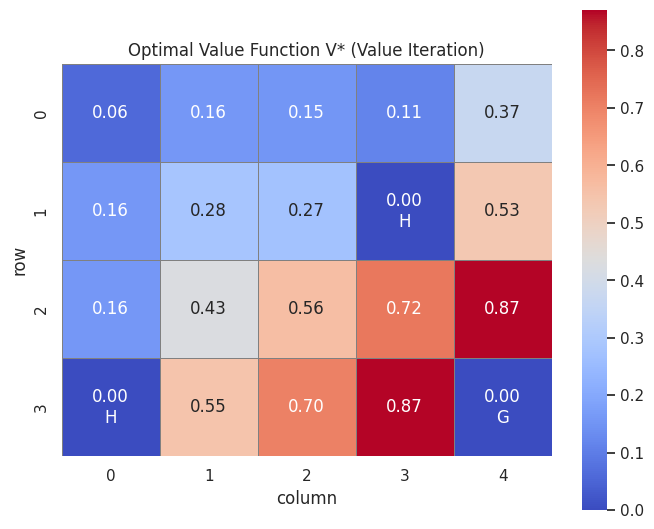

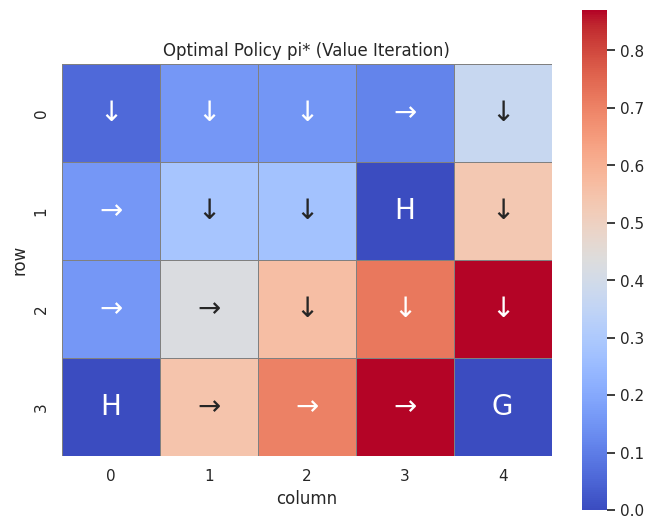

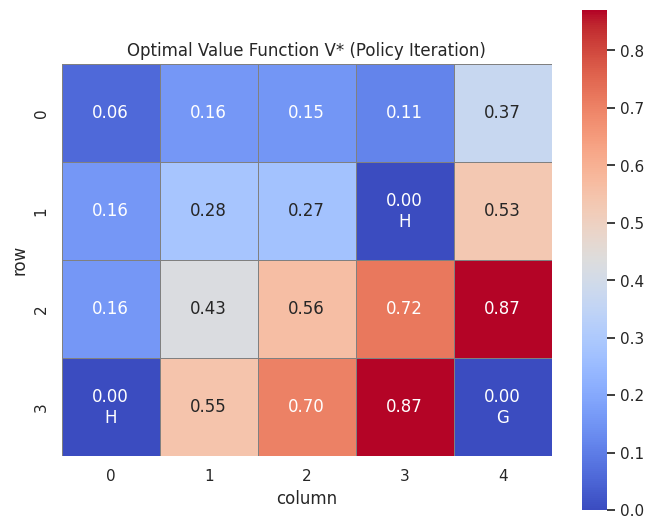

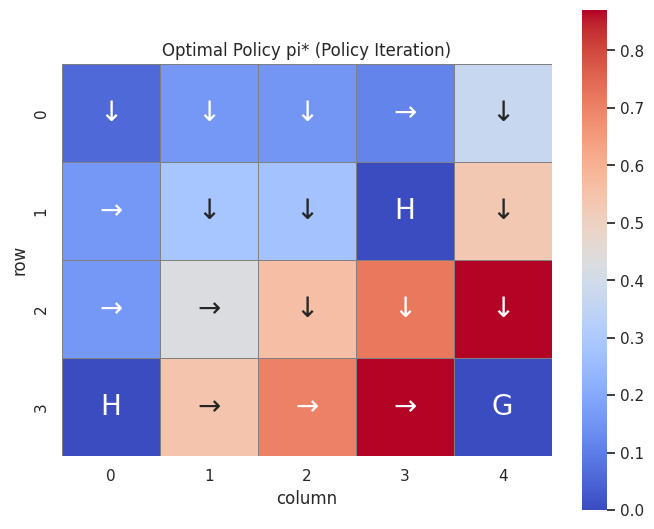

In [9]:
plot_value_function(V_vi, "Optimal Value Function V* (Value Iteration)", env.unwrapped)
plot_policy(policy_vi, "Optimal Policy pi* (Value Iteration)", env.unwrapped, V=V_vi)

plot_value_function(V_pi, "Optimal Value Function V* (Policy Iteration)", env.unwrapped)
plot_policy(policy_pi, "Optimal Policy pi* (Policy Iteration)", env.unwrapped, V=V_pi)

## 7. How much work did each method do?

In [10]:
print("%-20s%14s%16s%12s" % ("method", "outer iters", "Bellman sweeps", "time [ms]"))
print("-" * 62)
for name in ("Policy Iteration", "Value Iteration"):
    st = RUN_STATS[name]
    print("%-20s%14d%16d%12.1f"
          % (name, st["iterations"], st["sweeps"], 1000 * st["time_s"]))

method                 outer iters  Bellman sweeps   time [ms]
--------------------------------------------------------------
Policy Iteration                 7             436        19.2
Value Iteration                 28              28         5.8


## 8. Results and conclusions

Both methods return **exactly the same** optimal policy and value function
(`max|V_PI − V_VI| ≈ 5e-12`, which is pure floating-point noise):

```
    ↓  ↓  ↓  →  ↓
    →  ↓  ↓  H  ↓
    →  →  ↓  ↓  ↓
    H  →  →  →  G
```

Every arrow flows toward the goal at (3,4) while bending away from the two holes.
The clearest example is **state 9 = (1,4)**: the policy plays `↓` instead of `←`,
because a leftward slip could drop the agent into the hole at state 8. This is the
0.1 slip probability being priced into the policy - with a deterministic
environment the greedy shortcut would win.

### Policy Iteration vs Value Iteration

| | Policy Iteration | Value Iteration |
|---|---|---|
| Outer iterations | **7** | 28 |
| Total Bellman sweeps | 436 | **28** |
| Runtime | 10.6 ms | **3.5 ms** |
| Stopping rule | exact (policy stable) | threshold θ |

**Advantages of Policy Iteration**

* Very few outer iterations - each improvement is a large jump in policy space,
  and the number of iterations is bounded by the (finite) number of policies.
* Terminates **exactly**: a stable greedy policy is optimal, so no θ is needed.
* The evaluation step can be replaced by directly solving the linear system
  (20×20 here), which makes each iteration cheap for small state spaces.

**Disadvantages of Policy Iteration**

* Every outer iteration runs a *full* policy evaluation to convergence -
  436 sweeps in total here versus 28 for VI.
* Much more expensive per iteration, and the effort spent on precisely evaluating
  an intermediate policy that is about to be discarded is largely wasted.

**Advantages of Value Iteration**

* One cheap Bellman optimality backup per sweep, no inner loop, trivial to
  implement.
* On this MDP it is roughly 3× faster in wall-clock time.

**Disadvantages of Value Iteration**

* Converges only asymptotically, so it needs an arbitrary threshold θ.
* The number of sweeps grows as γ → 1 (roughly `log θ / log γ`), so for
  long-horizon problems VI can need many more sweeps.

**Conclusion.** On a 20-state MDP with γ = 0.95, Value Iteration is the better
choice: same answer, a fraction of the work. Policy Iteration pays off when γ is
close to 1 (few improvements still suffice while VI would need hundreds of
sweeps) or when policy evaluation can be solved in closed form. In practice
*modified policy iteration* - truncating the evaluation after k sweeps -
interpolates between the two and is usually the fastest of all.

Both share the same fundamental limitation: they need the **full model** `P`.
Assignments 2-4 drop that assumption.